In [1]:
import numpy as np
import matplotlib.pyplot as plt
from thinkdsp import Wave, read_wave

Упражнение 10.1

In [3]:
impulse = read_wave('180960__kleeb__gunshot.wav')
impulse_start = 0.12
impulse_segment = impulse.segment(start=impulse_start, duration=0.5)
impulse_segment.shift(-impulse_start)

In [4]:
impulse_segment.truncate(2**16)
impulse_segment.zero_pad(2**17)
impulse_segment.normalize()

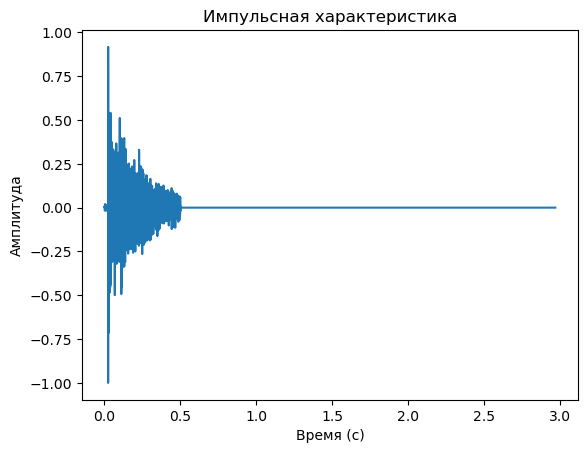

In [5]:
plt.plot(impulse_segment.ts, impulse_segment.ys)
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Импульсная характеристика')
plt.show()

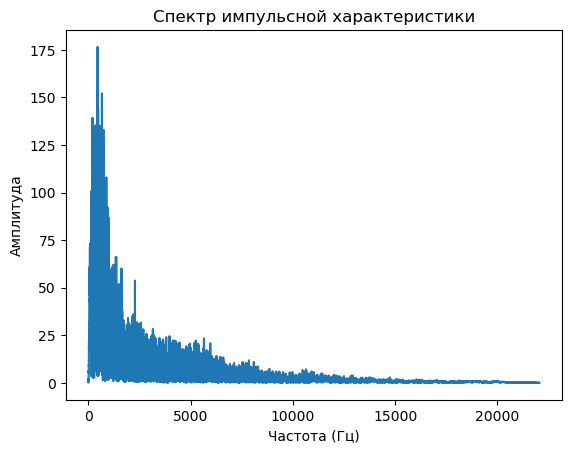

In [6]:
impulse_spectrum = impulse_segment.make_spectrum()
plt.plot(impulse_spectrum.fs, impulse_spectrum.amps)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Спектр импульсной характеристики')
plt.show()

In [7]:
signal = read_wave('92002__jcveliz__violin-origional.wav')
signal_start = 0.11
signal_segment = signal.segment(start=signal_start, duration=0.5)
signal_segment.shift(-signal_start)

In [8]:
signal_segment.truncate(2**16)
signal_segment.zero_pad(2**17)
signal_segment.normalize()

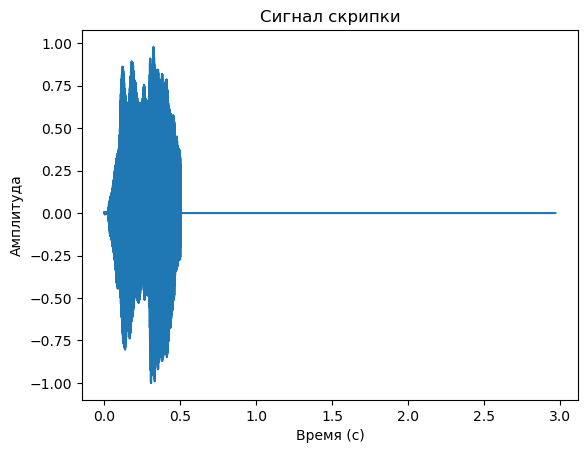

In [9]:
plt.plot(signal_segment.ts, signal_segment.ys)
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Сигнал скрипки')
plt.show()

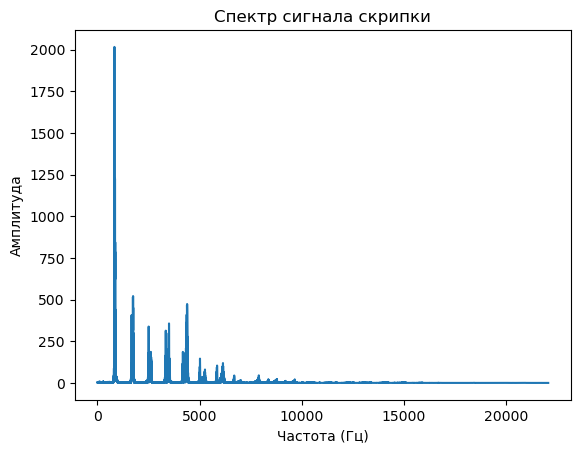

In [10]:
signal_spectrum = signal_segment.make_spectrum()
plt.plot(signal_spectrum.fs, signal_spectrum.amps)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Спектр сигнала скрипки')
plt.show()

In [11]:
result = (signal_spectrum * impulse_spectrum).make_wave()
result.normalize()

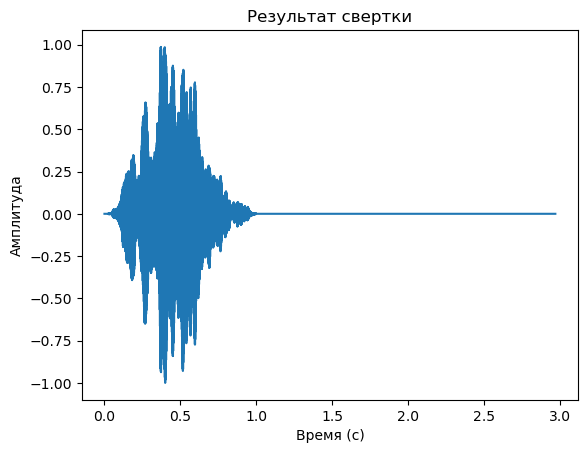

In [12]:
plt.plot(result.ts, result.ys)
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Результат свертки')
plt.show()

In [13]:
impulse_no_pad = impulse.segment(start=impulse_start, duration=0.5)
impulse_no_pad.shift(-impulse_start)
impulse_no_pad.truncate(2**16)
impulse_no_pad.normalize()
impulse_spectrum_no_pad = impulse_no_pad.make_spectrum()

signal_no_pad = signal.segment(start=signal_start, duration=0.5)
signal_no_pad.shift(-signal_start)
signal_no_pad.truncate(2**16)
signal_no_pad.normalize()
signal_spectrum_no_pad = signal_no_pad.make_spectrum()

result_no_pad = (signal_spectrum_no_pad * impulse_spectrum_no_pad).make_wave()
result_no_pad.normalize()

Упражнение 10.2

In [15]:
hall_response = read_wave('drum_exercise10.wav')
response_duration = 1.0
hall_response = hall_response.segment(start=0, duration=response_duration)
hall_response.normalize()

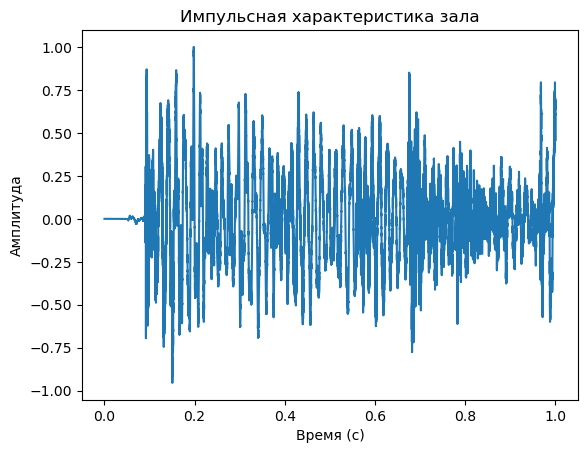

In [16]:
plt.plot(hall_response.ts, hall_response.ys)
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Импульсная характеристика зала')
plt.show()

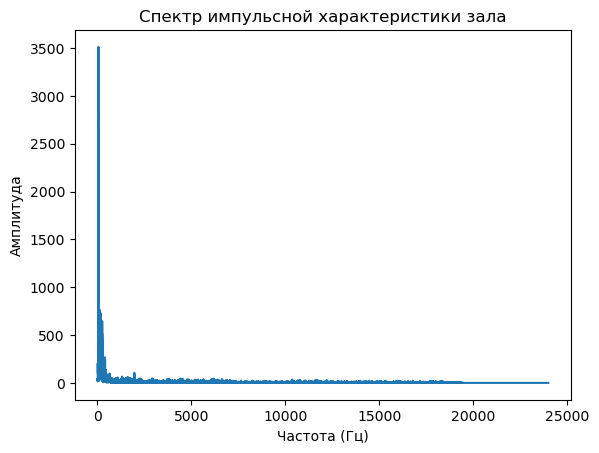

In [17]:
hall_spectrum = hall_response.make_spectrum()
plt.plot(hall_spectrum.fs, hall_spectrum.amps)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Спектр импульсной характеристики зала')
plt.show()

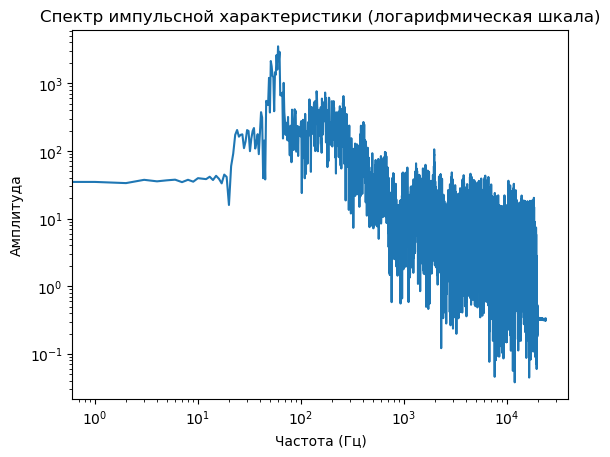

In [18]:
plt.plot(hall_spectrum.fs, hall_spectrum.amps)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Спектр импульсной характеристики (логарифмическая шкала)')
plt.show()

In [19]:
music = read_wave('92002__jcveliz__violin-origional.wav')
if music.framerate != hall_response.framerate:
    print(f"Частоты дискретизации различаются: {music.framerate} Гц (музыка) и {hall_response.framerate} Гц (импульс). Приводим к общей.")
    from scipy import signal
    music.ys = signal.resample(music.ys, int(len(music.ys) * hall_response.framerate / music.framerate))
    music.framerate = hall_response.framerate
    music.ts = np.arange(len(music.ys)) / music.framerate
music = music.segment(start=0, duration=response_duration)
music.normalize()

Частоты дискретизации различаются: 44100 Гц (музыка) и 48000 Гц (импульс). Приводим к общей.


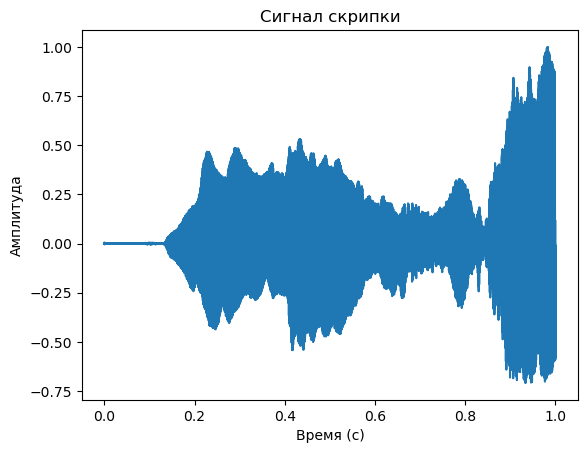

In [20]:
plt.plot(music.ts, music.ys)
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Сигнал скрипки')
plt.show()

In [48]:
music_spectrum = music.make_spectrum()
output_spectrum = (music_spectrum * hall_spectrum).make_wave()
output_spectrum.normalize()

In [22]:
output_convolve = music.convolve(hall_response)
output_convolve.normalize()

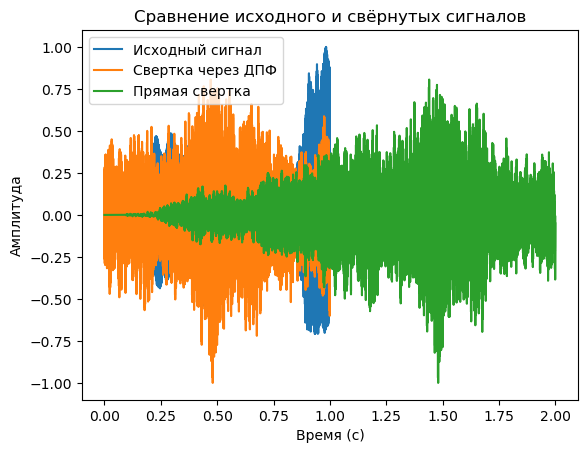

In [23]:
plt.plot(music.ts, music.ys, label='Исходный сигнал')
plt.plot(output_spectrum.ts, output_spectrum.ys, label='Свертка через ДПФ')
plt.plot(output_convolve.ts, output_convolve.ys, label='Прямая свертка')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Сравнение исходного и свёрнутых сигналов')
plt.legend()
plt.show()